<a href="https://colab.research.google.com/github/HamzaEric/facial-expression-autoencoders/blob/main/Notebooks/Basic_Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoder

An autoencoder is a neural network that learns to compress data into a smaller representation and then reconstruct the original data from that compressed representation.

Think of it like:

Image → Encoder → Latent representation → Decoder → Reconstructed image

In [27]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import ConcatDataset, DataLoader, TensorDataset
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.model_selection import train_test_split
import torch.optim as optim
from math import inf
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

### **FER2013 Dataset**

Before we can train an autoencoder, we must understand the data it will learn to reconstruct. In this project, we will work with the **FER2013 dataset** — a widely used benchmark for facial emotion recognition.  

The dataset contains grayscale facial images of size **48×48 pixels**, each labeled with one of seven basic emotions:

> **Angry, Disgust, Fear, Happy, Sad, Surprise, and Neutral**


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [5]:
!ls /kaggle/input/fer2013

test  train


In [6]:
!ls /kaggle/input/fer2013/train

angry  disgust	fear  happy  neutral  sad  surprise


In [7]:
!ls /kaggle/input/fer2013/test

angry  disgust	fear  happy  neutral  sad  surprise


In [8]:
!ls /kaggle/input/fer2013/train/angry

Training_10118481.jpg  Training_39444833.jpg  Training_70624216.jpg
Training_10120469.jpg  Training_3945046.jpg   Training_70632589.jpg
Training_10131352.jpg  Training_39456208.jpg  Training_70676714.jpg
Training_10161559.jpg  Training_3946595.jpg   Training_70691608.jpg
Training_1021836.jpg   Training_3950957.jpg   Training_70713840.jpg
Training_10269675.jpg  Training_39520111.jpg  Training_70726538.jpg
Training_10278738.jpg  Training_39536203.jpg  Training_70728333.jpg
Training_10290703.jpg  Training_39537307.jpg  Training_70731802.jpg
Training_10295477.jpg  Training_39549147.jpg  Training_70761180.jpg
Training_10315441.jpg  Training_39597202.jpg  Training_70765717.jpg
Training_10316849.jpg  Training_39614591.jpg  Training_70773407.jpg
Training_10333072.jpg  Training_39616340.jpg  Training_70796272.jpg
Training_10334355.jpg  Training_39631332.jpg  Training_70836368.jpg
Training_10345473.jpg  Training_39653498.jpg  Training_70912637.jpg
Training_10422050.jpg  Training_39717008.jpg  Tr

# Save the Dataset as .npz for usability

In [10]:
DATA_DIR_TRAIN = "/kaggle/input/fer2013/train"
DATA_DIR_TEST = "/kaggle/input/fer2013/test"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

print("Loading image directories...")
train_set = ImageFolder(root=DATA_DIR_TRAIN, transform=transform)
test_set = ImageFolder(root=DATA_DIR_TEST, transform=transform)

full_dataset = ConcatDataset([train_set, test_set])
total_images = len(full_dataset)

loader = DataLoader(full_dataset, batch_size=total_images, shuffle=False)
X_tensor, y_tensor = next(iter(loader))

# Formattted X to match your NPZ structure (N, 48, 48)
X_full = X_tensor.squeeze(1).numpy()
y_raw = y_tensor.numpy()

# Alphabetical: 0:angry, 1:disgust, 2:fear, 3:happy, 4:neutral, 5:sad, 6:surprise
# FER2013 Standard: 0:Angry, 1:Disgust, 2:Fear, 3:Happy, 4:Sad, 5:Surprise, 6:Neutral
label_mapping = {0: 0, 1: 1, 2: 2, 3: 3, 4: 6, 5: 4, 6: 5}
y_full = np.vectorize(label_mapping.get)(y_raw).astype(np.int64)

drive_path = "/content/drive/MyDrive"
np.savez_compressed(f"{drive_path}/fer2013_full.npz", X=X_full, y=y_full)
print(f"Successfully saved fer2013_full.npz with {len(X_full)} images!")

Loading image directories...
Successfully saved fer2013_full.npz with 35887 images!


In [11]:
data = np.load("/content/drive/MyDrive/fer2013_full.npz")
X, y = data["X"], data["y"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Pixel value range:", X.min(), "to", X.max())

Shape of X: (35887, 48, 48)
Shape of y: (35887,)
Pixel value range: 0.0 to 1.0


# Visualizing Sample Images

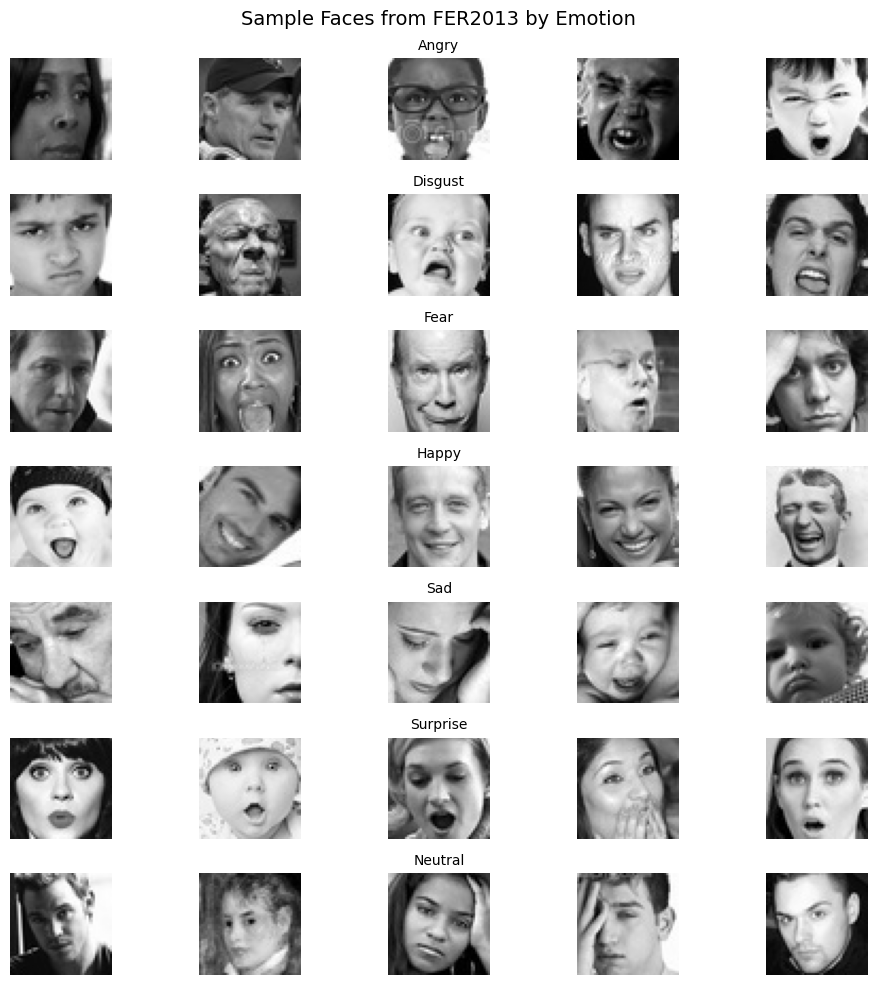

In [13]:
emotions = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

plt.figure(figsize=(10, 10))

for i, label in enumerate(range(7)):
    # Pick 5 random samples from each emotion
    idx = np.where(y == label)[0]
    sample_idx = np.random.choice(idx, size=5, replace=False)

    for j, img_idx in enumerate(sample_idx):
        plt.subplot(7, 5, i * 5 + j + 1)
        plt.imshow(X[img_idx], cmap="gray")
        if j == 2:
            plt.title(emotions[label], fontsize=10)
        plt.axis("off")

plt.suptitle("Sample Faces from FER2013 by Emotion", fontsize=14)
plt.tight_layout()
plt.show()

# Class Distribution

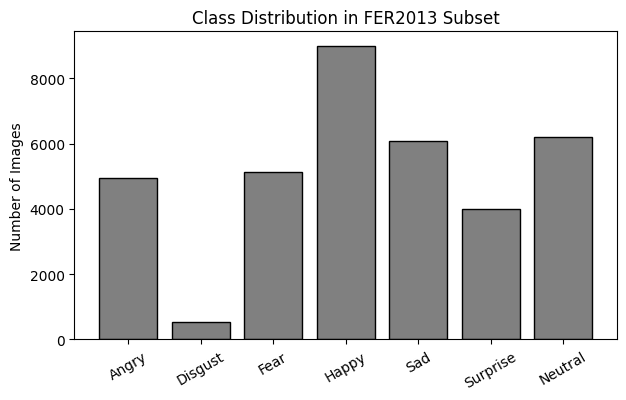

{'Angry': np.int64(4953), 'Disgust': np.int64(547), 'Fear': np.int64(5121), 'Happy': np.int64(8989), 'Sad': np.int64(6077), 'Surprise': np.int64(4002), 'Neutral': np.int64(6198)}


In [14]:
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(7, 4))
plt.bar(emotions, counts, color="gray", edgecolor="black")
plt.title("Class Distribution in FER2013 Subset")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()

print(dict(zip(emotions, counts)))

### **Reflection**

The class distribution shows that the FER2013 subset is highly imbalanced. The Happy class contains the largest number of images (8,989), while Disgust contains only 547 images. The other emotions fall between these two extremes. This imbalance is important because the autoencoder may learn representations that are influenced more strongly by classes with larger numbers of training examples. As a result, common expressions such as happiness may be represented more effectively than less frequent expressions such as disgust. This reflection shows the importance of examining the dataset before training and considering techniques such as balanced sampling or data augmentation when necessary.


# Autoencoder workflow

An **autoencoder** is a type of **neural network** designed to learn efficient representations of data in an *unsupervised* way.  
Its goal is not to predict a label, but to **reproduce its input** as closely as possible.

Conceptually, the autoencoder consists of three main parts:

> **Encoder → Latent Space → Decoder**

Let’s unpack what each part does:

- **Encoder:**  
  This part compresses the input image $x$ into a smaller, more compact form.  
  It extracts key patterns — such as eye position, mouth curvature, and general face shape — and discards unnecessary pixel-level details.

- **Latent Space (or Bottleneck):**  
  This is the “compressed summary” of the input, often represented as a low-dimensional vector $z$.  
  Here, the model captures **essential features** that describe the data efficiently.  
  Each point in this latent space encodes meaningful characteristics of the original image.

- **Decoder:**  
  This part attempts to reconstruct the original image $\hat{x}$ from the latent representation $z$.  
  The decoder learns to reverse the compression — like expanding the summary back into the full image.

**Schematic Representation**

We can visualize an autoencoder in a simple schematic form:

```text
       Input (48×48 face)
               │
               ▼
           [ Encoder ]
     (reduces dimensionality)
               │
               ▼
    [ Latent Representation ]
               │
               ▼
           [ Decoder ]
      (reconstructs the input)
               │
               ▼
    Output (Reconstructed face)
```

This structure is symmetrical — what the encoder compresses, the decoder tries to expand back.

**The Learning Objective**

To train an autoencoder, we compare the reconstructed image $\hat{x}$ with the original input $x$.  
The goal is to make them as close as possible.  

This is done using a **reconstruction loss**, often the **Mean Squared Error (MSE)**:

$$
L = \frac{1}{N}\sum_{i=1}^{N} (x_i - \hat{x}_i)^2
$$

Here:
- $x_i$ = original input image  
- $\hat{x}_i$ = reconstructed image produced by the network  
- $N$ = number of training samples  

By minimizing this loss, the model learns to **compress and reconstruct** data in a way that preserves its most important structures

# **Building a Basic Autoencoder in PyTorch**

Because each face image is grayscale with size **48×48**, we first **flatten** it into a vector of length **2,304**. The encoder compresses this vector into a **128-dimensional latent representation**, and the decoder expands it back to **2,304** values. Finally, we **reshape** the output vector to recover the original **48×48** image.

> We use `Sigmoid` at the output so pixel predictions lie in the range $[0, 1]$, matching our normalized inputs.

In [16]:
# Flattened input size for 48×48 grayscale images
INPUT_DIM = 48 * 48         # 2304
LATENT_DIM = 128

class FC_Autoencoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        # Encoder: 2304 -> 512 -> 128
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, latent_dim),
            nn.ReLU(inplace=True),
        )
        # Decoder: 128 -> 512 -> 2304
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, input_dim),
            nn.Sigmoid()  # constrain output to [0, 1]
        )

    def forward(self, x):
        """
        x: (N, 1, 48, 48) or (N, 48, 48)
        returns: reconstruction with same shape as input
        """
        # Ensure shape is (N, 48, 48)
        if x.dim() == 4:        # (N, 1, 48, 48)
            x = x.squeeze(1)
        # Flatten to (N, 2304)
        n = x.size(0)
        x_flat = x.view(n, -1)
        # Encode -> Decode
        z = self.encoder(x_flat)
        x_hat_flat = self.decoder(z)
        # Reshape back to (N, 48, 48)
        x_hat = x_hat_flat.view(n, 48, 48)
        # Add channel dim back to be consistent with PyTorch image conventions
        x_hat = x_hat.unsqueeze(1)  # (N, 1, 48, 48)
        return x_hat

**Instantiate the Model and Verify Shapes**

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FC_Autoencoder().to(device)

# Sanity check with a dummy batch
with torch.no_grad():
    dummy = torch.rand(8, 1, 48, 48, device=device)  # batch of 8 images in [0, 1]
    out = model(dummy)
    print("Input shape :", tuple(dummy.shape))
    print("Output shape:", tuple(out.shape))

Input shape : (8, 1, 48, 48)
Output shape: (8, 1, 48, 48)


>We expect to see Input shape : (8, 1, 48, 48) and Output shape: (8, 1, 48, 48).</br>
This confirms our flatten → encode → decode → reshape pipeline is consistent.

*We use 128 hidden units as a balanced choice between model capacity and computational efficiency. In deeper/larger models we sometimes reduce to 64 to prevent overfitting or reduce parameters.*

*Batch size of 128 is used for more stable gradient estimates. Later, we use 64 to allow more frequent parameter updates, which can help convergence.*

**Lightweight Model Summary**

In [18]:
def count_params(net):
    return sum(p.numel() for p in net.parameters() if p.requires_grad)

print(model)  # architecture overview
print("Trainable parameters:", count_params(model))

FC_Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2304, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=2304, bias=True)
    (3): Sigmoid()
  )
)
Trainable parameters: 2493824


# Training The Autoencoder

In [20]:
try:
    X, y
except NameError:
    data = np.load("/content/drive/MyDrive/fer2013_full.npz")
    X, y = data["X"], data["y"]

# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Convert to torch tensors and add channel dimension (N, 1, 48, 48)
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)

# Build datasets and dataloaders
train_ds = TensorDataset(X_train_t)  # labels not needed
test_ds  = TensorDataset(X_test_t)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(test_loader)

(225, 57)

In [22]:
model = model.to(device)  # reuse the model defined earlier

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

**Training Loop**

In [24]:
EPOCHS = 100
best_test_loss = inf

for epoch in range(1, EPOCHS + 1):
    # ----- Train -----
    model.train()
    running_train_loss = 0.0
    for (xb,) in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        xhat = model(xb)
        loss = criterion(xhat, xb)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * xb.size(0)

    avg_train_loss = running_train_loss / len(train_ds)

    # ----- Evaluate (reconstruction on held-out set) -----
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for (xb,) in test_loader:
            xb = xb.to(device)
            xhat = model(xb)
            loss = criterion(xhat, xb)
            running_test_loss += loss.item() * xb.size(0)

    avg_test_loss = running_test_loss / len(test_ds)

    print(f"Epoch {epoch:02d} | train MSE: {avg_train_loss:.5f} | test MSE: {avg_test_loss:.5f}")

    # Optionally keep best weights
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}


Epoch 01 | train MSE: 0.03278 | test MSE: 0.02110
Epoch 02 | train MSE: 0.01877 | test MSE: 0.01677
Epoch 03 | train MSE: 0.01619 | test MSE: 0.01528
Epoch 04 | train MSE: 0.01470 | test MSE: 0.01402
Epoch 05 | train MSE: 0.01358 | test MSE: 0.01307
Epoch 06 | train MSE: 0.01284 | test MSE: 0.01269
Epoch 07 | train MSE: 0.01231 | test MSE: 0.01235
Epoch 08 | train MSE: 0.01189 | test MSE: 0.01172
Epoch 09 | train MSE: 0.01140 | test MSE: 0.01106
Epoch 10 | train MSE: 0.01112 | test MSE: 0.01118
Epoch 11 | train MSE: 0.01088 | test MSE: 0.01068
Epoch 12 | train MSE: 0.01067 | test MSE: 0.01055
Epoch 13 | train MSE: 0.01045 | test MSE: 0.01050
Epoch 14 | train MSE: 0.01032 | test MSE: 0.01017
Epoch 15 | train MSE: 0.01009 | test MSE: 0.01026
Epoch 16 | train MSE: 0.01002 | test MSE: 0.01017
Epoch 17 | train MSE: 0.00991 | test MSE: 0.01034
Epoch 18 | train MSE: 0.00977 | test MSE: 0.00982
Epoch 19 | train MSE: 0.00978 | test MSE: 0.00984
Epoch 20 | train MSE: 0.00967 | test MSE: 0.00995


In [25]:
if 'best_state' in globals():
    model.load_state_dict(best_state)
torch.save(model.state_dict(), "ae_model.pth")

# **Visualizing Reconstructions**

The autoencoder is trained,
By placing the original image next to its reconstruction, we can visually inspect which facial details are preserved and which are blurred. This simple check helps us develop intuition about how the encoder compresses information and how the decoder rebuilds the image from its latent representation.

> As we compare pairs, we should pay attention to features like the outline of the face, eyes, eyebrows, and mouth. Even when fine texture is lost, the model often preserves the overall structure and key emotion-related cues.

**Show Original vs. Reconstructed Pairs**

The code below takes a small batch from the test set, runs it through the model, and plots a grid with **five rows** and **two columns**: the **original** on the left and its **reconstruction** on the right.


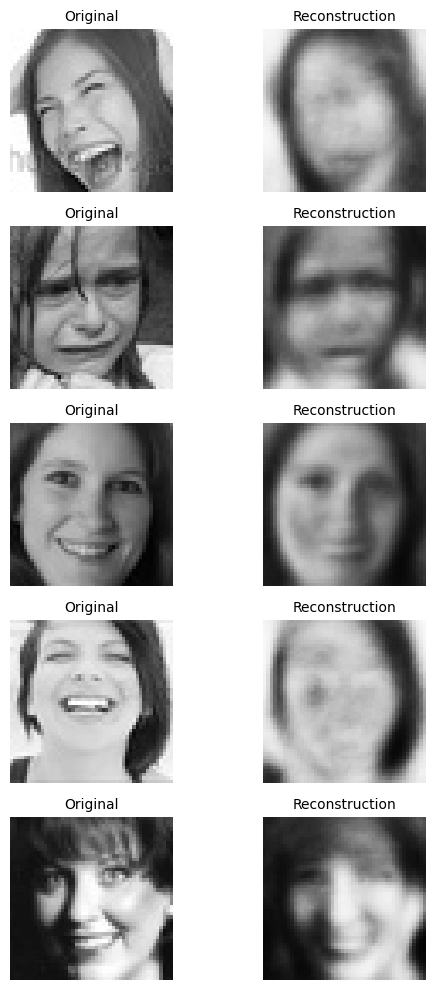

In [26]:
model.eval()
xb = next(iter(test_loader))[0].to(next(model.parameters()).device)

with torch.no_grad():
    xhat = model(xb)

# Move to CPU and convert to numpy for plotting
orig = xb.detach().cpu().numpy()      # (N, 1, 48, 48)
reco = xhat.detach().cpu().numpy()    # (N, 1, 48, 48)

n_rows = min(5, orig.shape[0])

fig, axes = plt.subplots(n_rows, 2, figsize=(6, 2*n_rows))
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)  # ensure 2D indexing

for i in range(n_rows):
    # Original
    axes[i, 0].imshow(orig[i, 0, :, :], cmap="gray", vmin=0.0, vmax=1.0)
    axes[i, 0].set_title("Original", fontsize=10)
    axes[i, 0].axis("off")

    # Reconstruction
    axes[i, 1].imshow(reco[i, 0, :, :], cmap="gray", vmin=0.0, vmax=1.0)
    axes[i, 1].set_title("Reconstruction", fontsize=10)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

**Reflection**

- Reconstructions often appear slightly smoother than the originals. This is normal: by compressing the image into a low-dimensional latent vector, the model tends to remove high-frequency details (fine texture and noise).

- The model usually preserves global structure: head contour, eye placement, brow shape, and mouth curve. These structures carry a lot of the emotional signal.


# **Interpreting Latent Representations(Dimensionality Reduction)**

So far, we focused on **reconstruction quality** — what comes out of the decoder.  
But equally important is what happens **inside the model**: the **latent space** learned by the encoder.

This latent space is a **compressed (128-D)** representation of each face.  
Even without labels, the autoencoder tries to store the **most informative visual features** needed to reconstruct the image.

**What kind of features could the latent space encode?**
- Face symmetry or orientation  
- Lighting and shading  
- Shape of mouth, eyes, eyebrows  
- Subtle emotional expressions  

> The fascinating part: the autoencoder discovers these features **without any emotion labels!**


**Can Emotions Be Separated in Latent Space?**

To explore this, we will project the 128-D latent vectors into **2D** using:

- **PCA** – linear projection (captures global variance)
- **t-SNE** – nonlinear projection (captures local structure)

Rather than all 7 emotions at once (which can be visually noisy),  
we will focus on **pairs of emotions** where we might expect visual differences.

We will examine:

 **Happy vs Surprise** (both positive, but different expressions)  
 **Happy vs Disgust** (emotionally and visually contrasting)


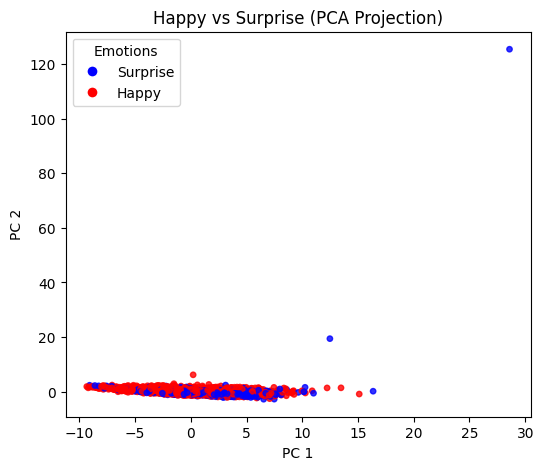

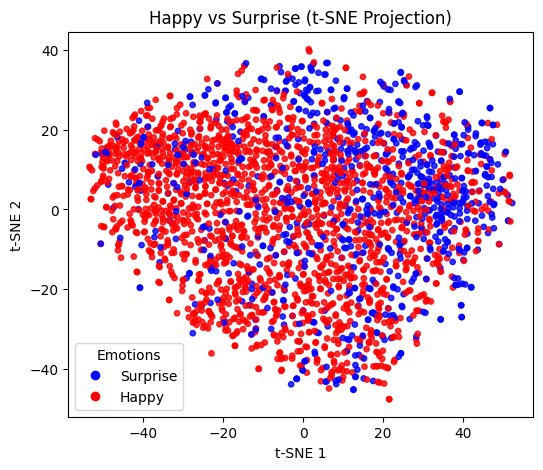

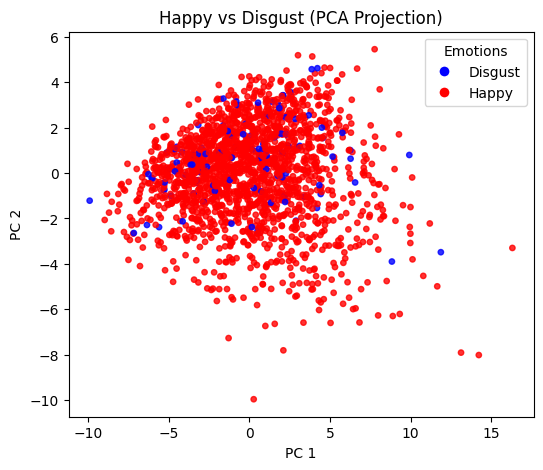

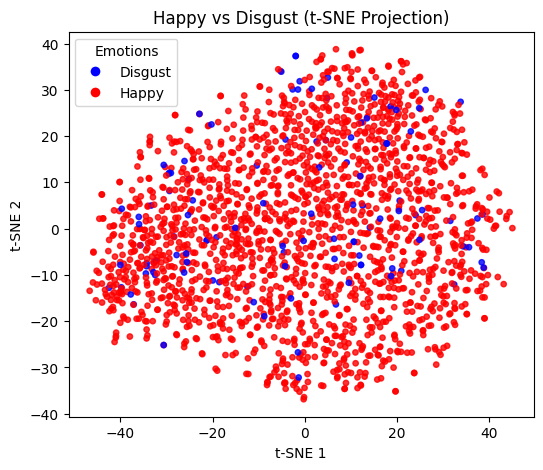

In [28]:
model.eval()
latents, labels = [], []

with torch.no_grad():
    for xb, in test_loader:
        xb = xb.to(next(model.parameters()).device)
        n = xb.size(0)
        z = model.encoder(xb.view(n, -1))  # (N, 128)
        latents.append(z.cpu().numpy())

latents = np.concatenate(latents, axis=0)
labels = y_test  # from earlier split

# Emotion indices
HAPPY = 3
SURPRISE = 5
DISGUST = 1

emotion_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

pairs = [
    (HAPPY, SURPRISE, f"Happy vs Surprise"),
    (HAPPY, DISGUST, f"Happy vs Disgust"),
]

for a, b, title in pairs:
    # Filter the two classes
    mask = np.isin(labels, [a, b])
    L = latents[mask]
    y_pair = labels[mask]

    # Remap to 0 and 1 for consistent coloring
    y_binary = (y_pair == a).astype(int)  # 1 = Happy, 0 = Other emotion

    # Standardize latent vectors
    L_std = StandardScaler().fit_transform(L)

    # ----- PCA (2D) -----
    L_pca = PCA(n_components=2, random_state=42).fit_transform(L_std)

    plt.figure(figsize=(6,5))
    scatter = plt.scatter(L_pca[:,0], L_pca[:,1],
                          c=y_binary, cmap="bwr", s=15, alpha=0.8)

    # Legend
    labels_legend = [emotion_names[a], emotion_names[b]]
    handles = [
        plt.Line2D([], [], marker="o", color="w",
                   markerfacecolor="blue", markersize=8, label=labels_legend[1]),  # 0 class
        plt.Line2D([], [], marker="o", color="w",
                   markerfacecolor="red", markersize=8, label=labels_legend[0])   # 1 class (Happy)
    ]
    plt.legend(handles=handles, title="Emotions", loc="best")

    plt.title(f"{title} (PCA Projection)")
    plt.xlabel("PC 1"); plt.ylabel("PC 2")
    plt.show()

    # ----- t-SNE (with PCA-30 init) -----
    L_pca_30 = PCA(n_components=30, random_state=42).fit_transform(L_std)
    L_tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=42
    ).fit_transform(L_pca_30)

    plt.figure(figsize=(6,5))
    plt.scatter(L_tsne[:,0], L_tsne[:,1],
                c=y_binary, cmap="bwr", s=15, alpha=0.8)

    # Legend again
    plt.legend(handles=handles, title="Emotions", loc="best")

    plt.title(f"{title} (t-SNE Projection)")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.show()

**What Do These Plots Tell Us?**

- If **Happy and Surprise** tend to form loose groups, it suggests the model captures subtle expression differences (e.g., mouth open, eyes widened).
- If **Happy and Disgust** separate more clearly, specially in t-SNE, it shows the model encodes contrasting facial features (smile vs nose scrunch).

Even if separation is not perfect:
- It still reveals that **unsupervised learning captures emotional structure** to some extent.  
- A simple autoencoder is already learning meaningful internal representations!

**Why Latent Spaces Matter**

Latent representations are the backbone of modern generative models:

- **VAEs** – add probabilistic structure to latent space ⇒ can **sample new data**
- **GANs** – generate realistic images through adversarial training
- **Diffusion / Transformers** – extend latent learning to high-resolution images and language

Our autoencoder is the **first step**:  
it learns to **compress** images and **reconstruct** them from a meaningful internal code.

# Convolutional Autoencoder

These extension not only make the model more expressive but also bridge the gap toward modern **deep generative architectures**.

**Adding Convolutional Layers for Spatial Feature Learning**

Our current autoencoder treats each 48×48 image as a flat vector of 2,304 pixels, ignoring the spatial relationships between them.  
By introducing **convolutional layers**, we can allow the model to directly exploit 2D structure — edges, contours, and local patterns — that are critical in face representation.

> A **Convolutional Autoencoder (ConvAE)** replaces fully connected layers with `Conv2d` and `ConvTranspose2d`, learning spatially-aware filters.  
> Such a model typically produces **sharper** and more **structurally coherent** reconstructions, even with fewer parameters.


# **Introducing Denoising Autoencoders**

Another fascinating variant is the Denoising Autoencoder (DAE).
Instead of reconstructing a clean input directly, we deliberately corrupt the input (for example, by adding noise or masking pixels) and train the model to reconstruct the original, noise-free version.

> This encourages the model to learn robust, noise-invariant representations, and it becomes better at capturing the underlying structure of the data rather than memorizing surface patterns.

Conceptually:

$$
x' = x + \text{noise}, \quad \hat{x} = f_\theta(x'), \quad L = \|x - \hat{x}\|^2
$$

This simple modification forms the basis for many later models that emphasize **stability** and **generalization**, including *denoising diffusion models* — one of the most powerful generative paradigms today.
